In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 

In [2]:
data_path = 'JetClass_gromov_delta_results_EMD'
loaded_data = {}
for file_path in os.listdir(data_path):
    loaded_data[file_path.split('_')[0]] = pd.read_csv(os.path.join(data_path, file_path))

IsADirectoryError: [Errno 21] Is a directory: 'JetClass_gromov_delta_results_EMD/test'

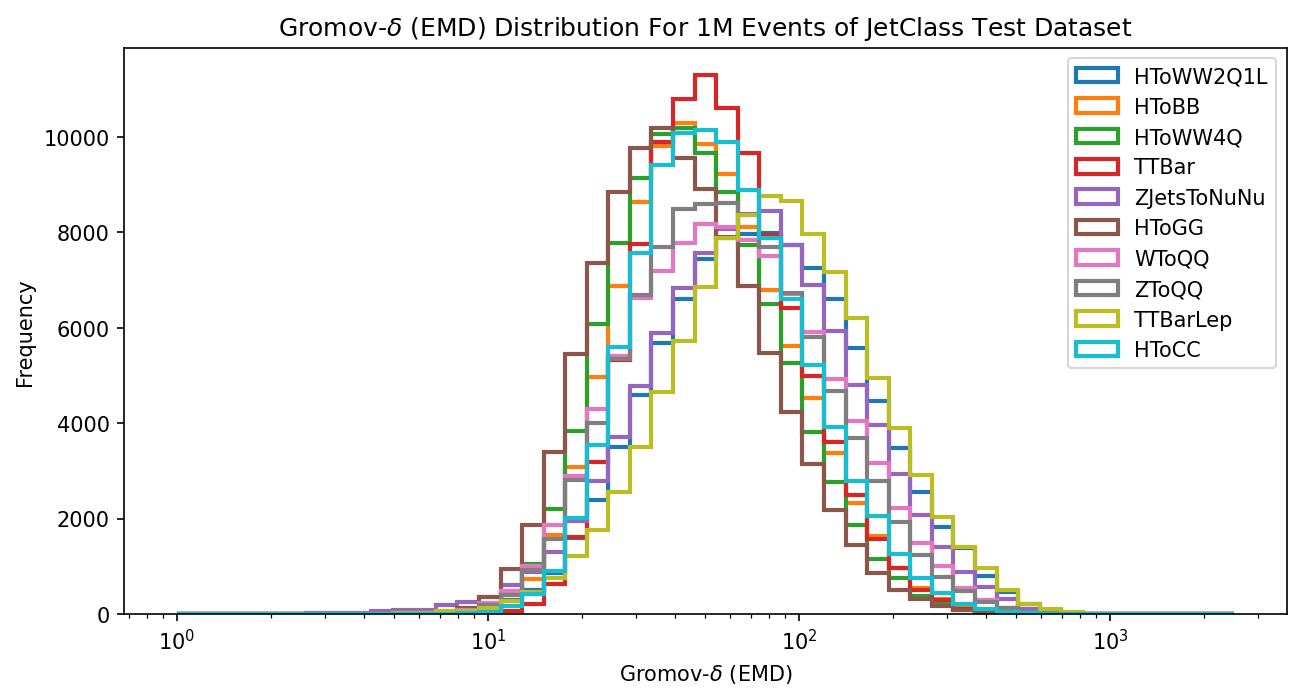

In [6]:
bins = np.logspace(0, np.log10(2500), 50)

plt.figure(figsize=(10, 5), dpi=150,facecolor='white')
for key in loaded_data.keys():
    plt.hist(loaded_data[key]['delta'], histtype='step', label=key, bins=bins, linewidth = 2)
plt.xlabel(f'Gromov-$\delta$ (EMD)')
plt.xscale('log')
plt.ylabel('Frequency')
plt.title('Gromov-$\delta$ (EMD) Distribution For 1M Events of JetClass Test Dataset')
plt.legend()
plt.show()

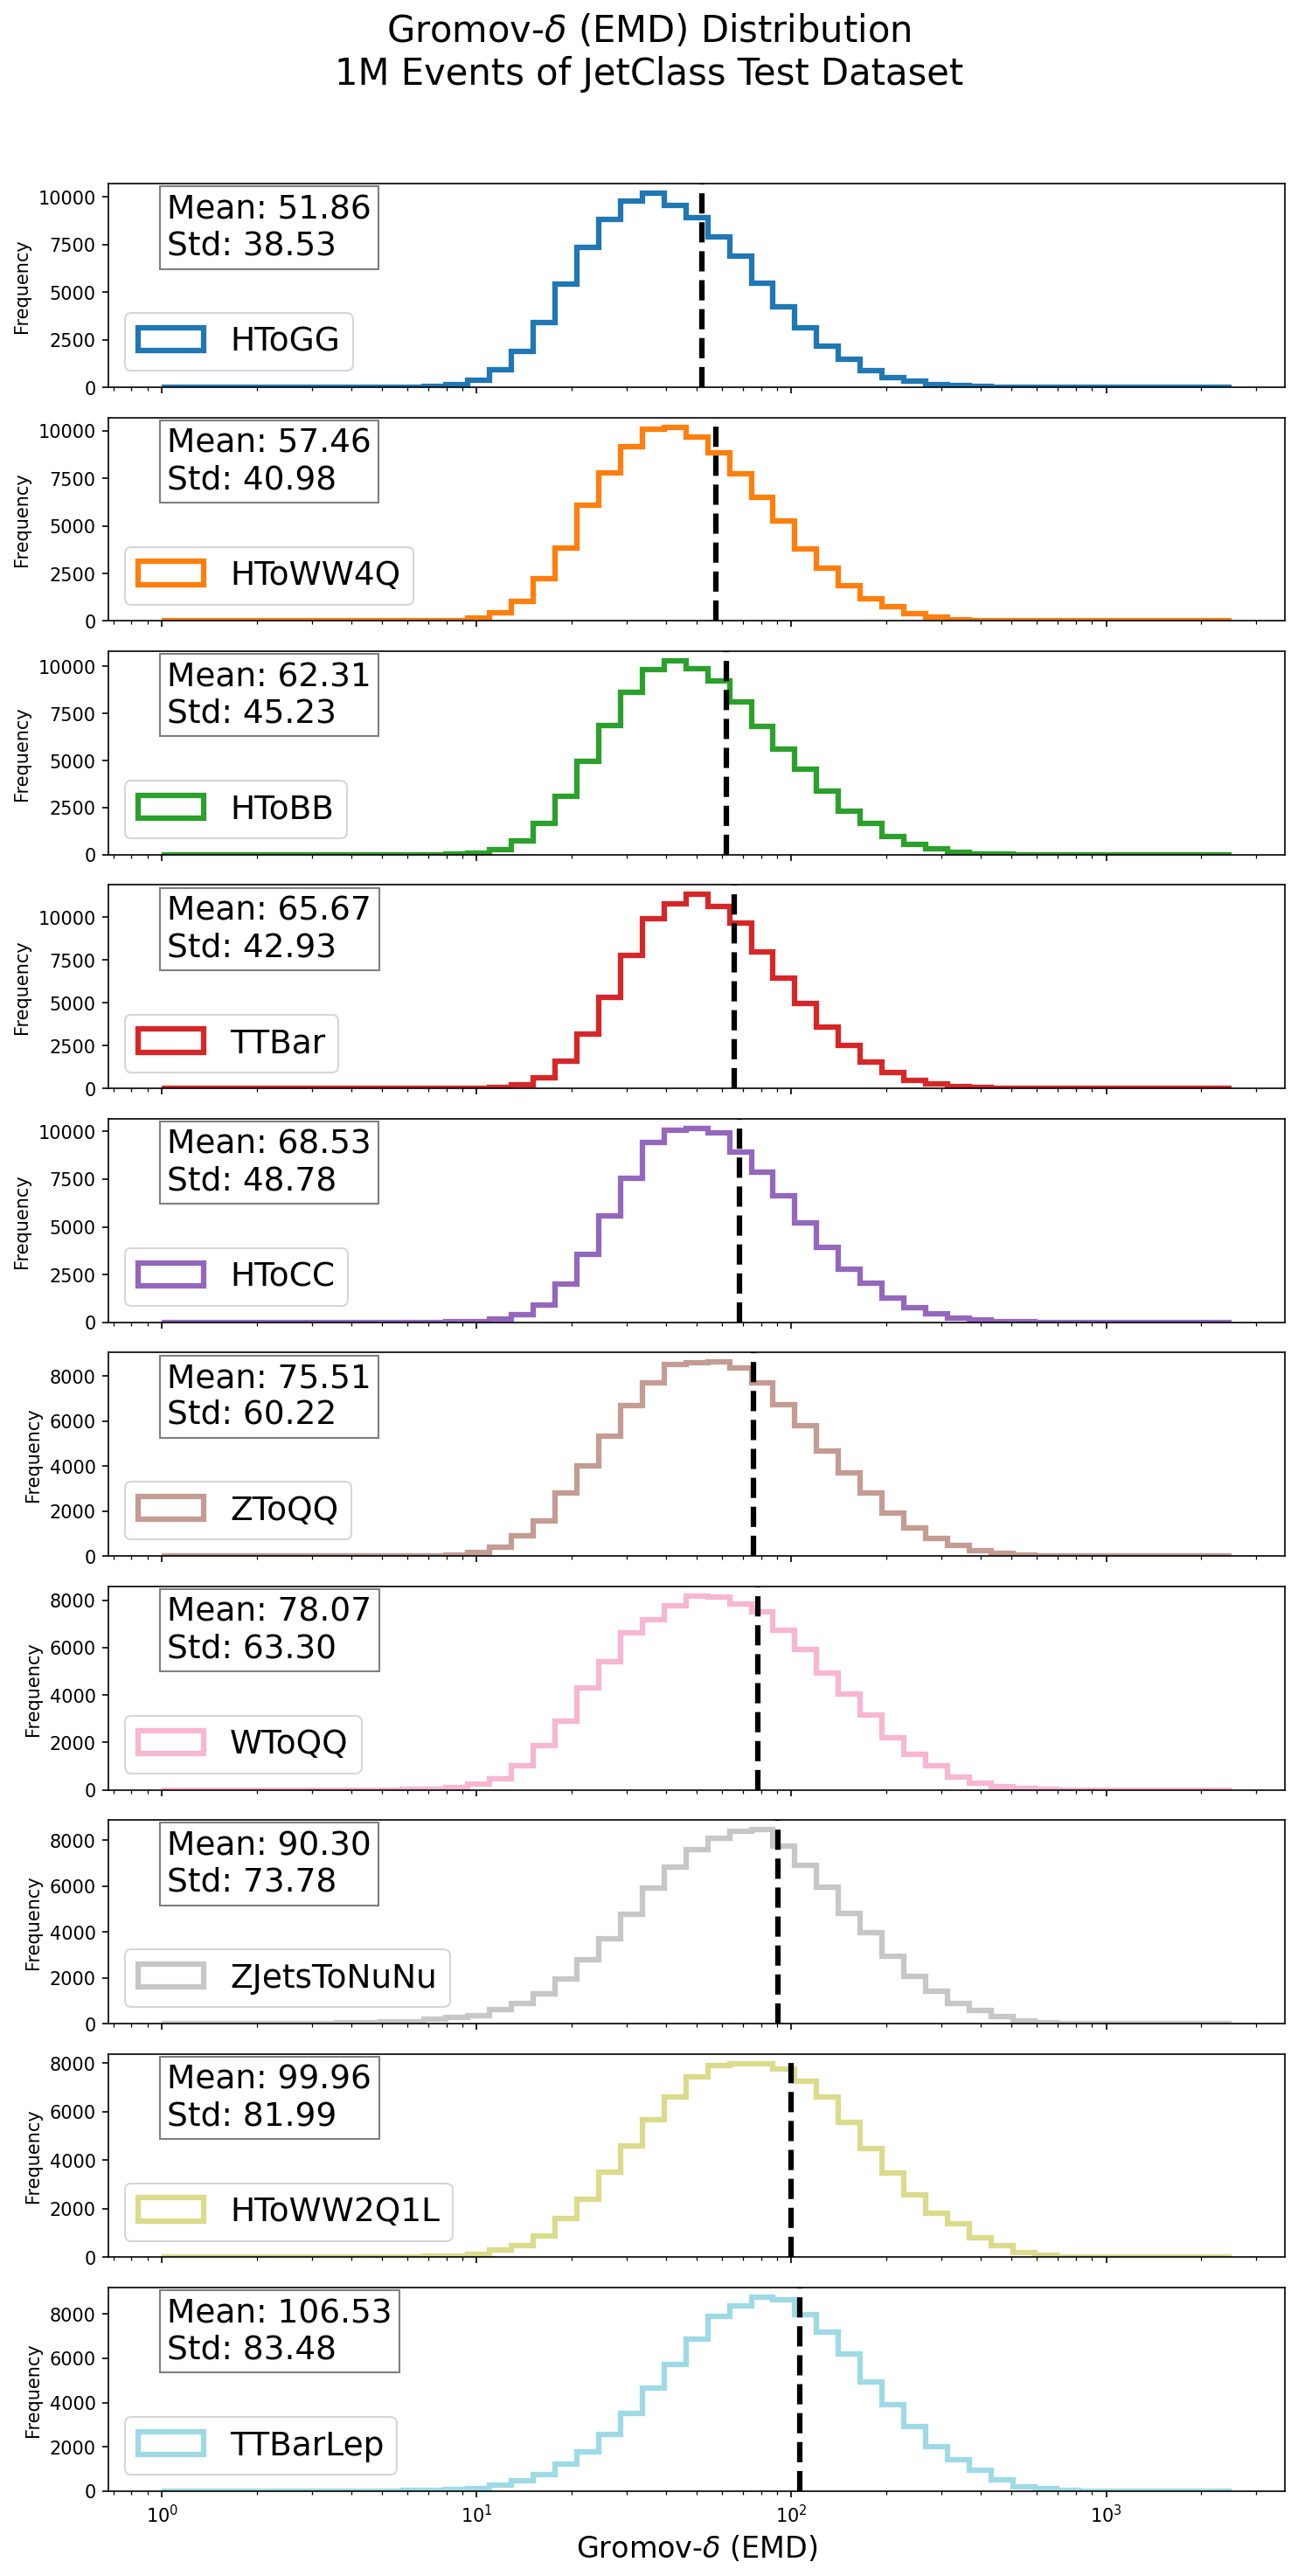

In [7]:
# Calculate the mean and standard deviation of the 'delta' column for each dataset
means = {key: data['delta'].mean() for key, data in loaded_data.items()}
stds = {key: data['delta'].std() for key, data in loaded_data.items()}

# Sort the keys based on the calculated means
sorted_keys = sorted(means, key=means.get)

fig, axs = plt.subplots(10, 1, figsize=(10, 20), dpi=150, sharex=True,facecolor='white')
colors = plt.cm.tab20(np.linspace(0, 1, len(loaded_data)))

for ax, key, color in zip(axs, sorted_keys, colors):
    data = loaded_data[key]
    ax.hist(data['delta'], histtype='step', label=key, bins=bins, linewidth=3, color=color)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize = 18, loc = 'lower left')
    mean = means[key]
    std = stds[key]
    ax.axvline(mean, color='k', linestyle='--', linewidth=3)
    ax.text(0.05, 0.95, f'Mean: {mean:.2f}\nStd: {std:.2f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5), fontsize=18)

axs[-1].set_xlabel(f'Gromov-$\delta$ (EMD)', fontsize = 16)
axs[-1].set_xscale('log')
fig.suptitle('Gromov-$\delta$ (EMD) Distribution\n1M Events of JetClass Test Dataset',fontsize = 20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()